# Structural Regime Shift Investigation

Three interlocking questions:

1. **Why does the MV optimizer give Trend low allocation?** How has that shifted since 2020?
2. **Did 2022 represent a structural correlation break?** Ukraine invasion + rate-hike cycle changed stock/bond dynamics.
3. **Does deficit/debt dynamics support a steepening bias?** If so, what does that imply for Trend?

Outputs → `output/structural/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
import io, urllib.request, warnings
warnings.filterwarnings('ignore')

# Paths
NB_DIR  = Path('.')                        # this notebook lives in Notebooks/
DATA    = Path('../data')
REG_OUT = NB_DIR / 'output' / 'regime'
OUT     = NB_DIR / 'output' / 'structural'
OUT.mkdir(parents=True, exist_ok=True)

# Styling
COLORS = {
    'trend':  '#2A9D8F',
    'stock':  '#8E3B46',
    'bond':   '#4F6D7A',
    '6040':   '#1F4E79',
    'neutral':'#6C757D',
    'light':  '#D9DEE7',
}
REGIME_COLORS = {
    'Bull Steepener':  '#2A9D8F',
    'Bear Steepener':  '#1F6B5C',
    'Bull Flattener':  '#E07070',
    'Bear Flattener':  '#8E3B46',
    'Steepener Twist': '#B08D57',
    'Flattener Twist': '#D4A96A',
    'Unclassified':    '#D9DEE7',
}

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

TRADING_DAYS = 252
print(f'Output directory: {OUT.resolve()}')

Output directory: /Users/luciemartin/Desktop/LowTide/LTCM_sp_2026/Notebooks/output/structural


In [2]:
# Load all data 
# 1. Dynamic MV weights (pre-computed)
dw = pd.read_csv(REG_OUT / 'q3_dynamic_weights_3asset.csv',
                 parse_dates=['date']).set_index('date').sort_index()

# 2. Regime labels (1990-2026)
reg = pd.read_excel(DATA / 'interest_rate_regimes.xlsx',
                    parse_dates=['date']).set_index('date').sort_index()

# 3. Daily returns for stock / bond / trend / 60-40
daily = pd.read_csv(NB_DIR / 'output' / 'merged_method1_vs_60_40_daily.csv',
                    parse_dates=['Dates']).set_index('Dates').sort_index()

ret = pd.DataFrame({
    'trend': daily['method1_strategy_return'],
    'stock': daily['spxt_return'],
    'bond':  daily['luattruu_return'],
    '6040':  daily['benchmark_strategy_return'],
}).dropna(how='all')
ret['regime'] = reg['regime_filtered'].reindex(ret.index, method='ffill')

# 4. Regime-averaged weights (for cross-reference)
avg_w = pd.read_csv(REG_OUT / 'q3_avg_weights_by_regime.csv').set_index('Regime')

print(f'Returns:        {ret.index.min().date()} → {ret.index.max().date()}  ({len(ret):,} days)')
print(f'Dynamic weights:{dw.index.min().date()} → {dw.index.max().date()}  ({len(dw):,} days)')
print(f'Regime data:    {reg.index.min().date()} → {reg.index.max().date()}  ({len(reg):,} days)')

Returns:        2002-01-01 → 2026-04-20  (6,340 days)
Dynamic weights:2001-05-04 → 2026-05-06  (6,524 days)
Regime data:    1990-10-17 → 2026-05-19  (8,903 days)


---
## Section 1 — Trend Allocation Over Time

The dynamic MV optimizer re-solves monthly on a **rolling 3-year window**. This means it reacts to history with a lag and "forgets" periods as they age out. The 2022 Bear Flattener was exceptional for Trend; as 2022 rolls out of the lookback window in 2025, Trend loses its track-record support.

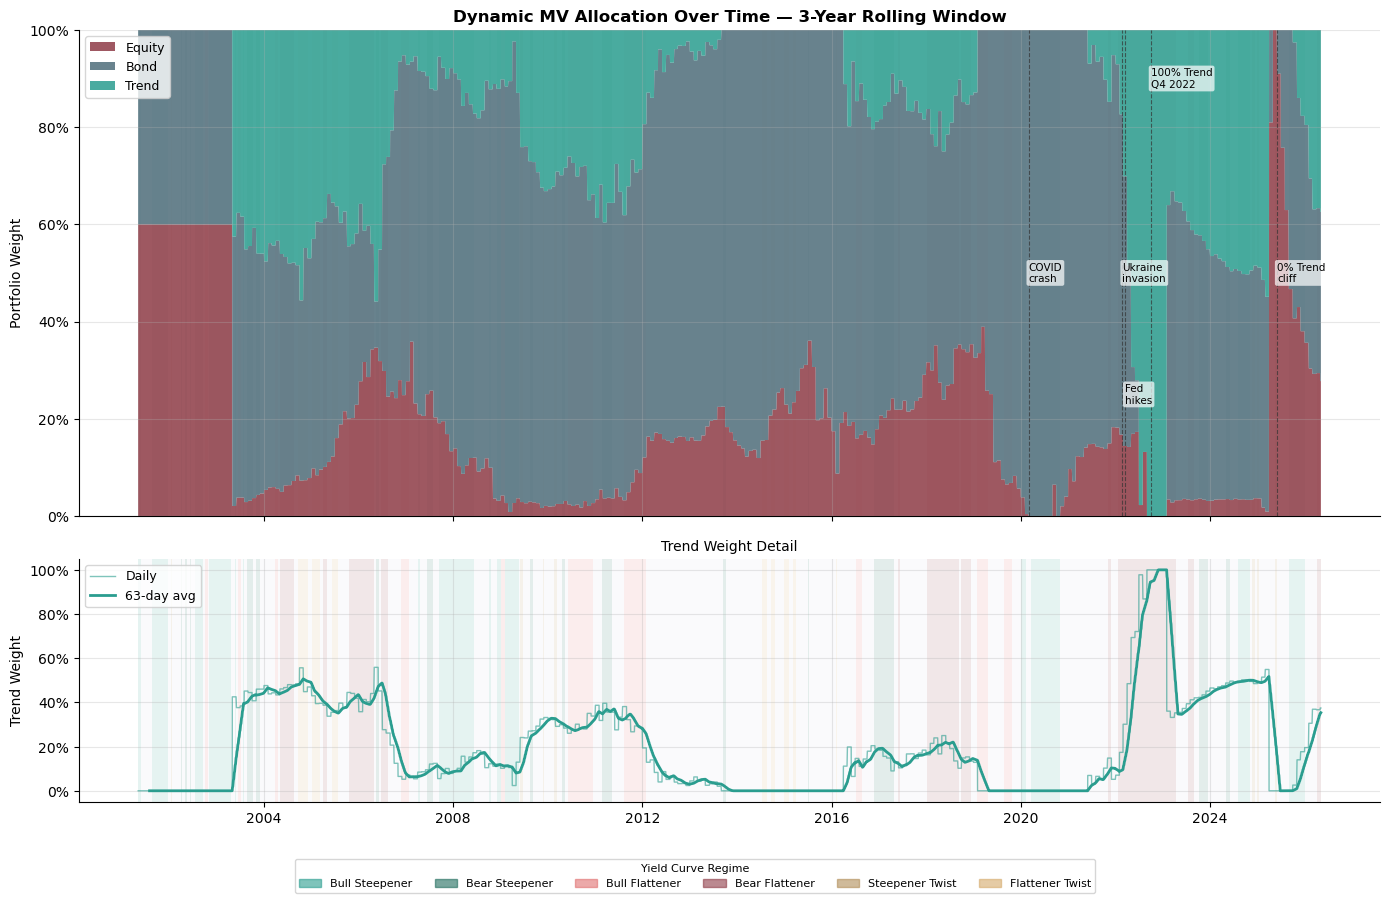

Saved → trend_allocation_timeline.png


In [3]:
# Quarterly averages 
dw_q = dw[['w_stock', 'w_bond', 'w_trend']].resample('QE').mean().round(3)
dw_q.columns = ['Stock', 'Bond', 'Trend']

# Regime band helper 
def add_regime_bands(ax, regime_series, alpha=0.12):
    """Shade background by regime."""
    s = regime_series.dropna()
    changes = s.ne(s.shift())
    starts = s.index[changes].tolist() + [s.index[-1]]
    for i in range(len(starts) - 1):
        r = s.iloc[s.index.get_loc(starts[i])]
        c = REGIME_COLORS.get(r, '#FFFFFF')
        ax.axvspan(starts[i], starts[i + 1], alpha=alpha, color=c, linewidth=0)

# Figure 
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

ax1, ax2 = axes

# Top: stacked area of weights
regime_aligned = reg['regime_filtered'].reindex(dw.index, method='ffill')
add_regime_bands(ax1, regime_aligned)

ax1.stackplot(dw.index,
              dw['w_stock'], dw['w_bond'], dw['w_trend'],
              labels=['Equity', 'Bond', 'Trend'],
              colors=[COLORS['stock'], COLORS['bond'], COLORS['trend']],
              alpha=0.85)

# Key event annotations
events = [
    ('2020-03-01', 'COVID\ncrash', 0.5),
    ('2022-02-24', 'Ukraine\ninvasion', 0.5),
    ('2022-03-16', 'Fed\nhikes', 0.25),
    ('2022-10-01', '100% Trend\nQ4 2022', 0.9),
    ('2025-06-01', '0% Trend\ncliff', 0.5),
]
for date_str, label, ypos in events:
    dt = pd.Timestamp(date_str)
    ax1.axvline(dt, color='#333333', linewidth=0.8, linestyle='--', alpha=0.7)
    ax1.text(dt, ypos, label, fontsize=7.5, ha='left', va='center',
             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

ax1.set_ylim(0, 1)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylabel('Portfolio Weight')
ax1.set_title('Dynamic MV Allocation Over Time — 3-Year Rolling Window', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

# Bottom: trend weight only, with rolling 1Y average
add_regime_bands(ax2, regime_aligned, alpha=0.12)
ax2.plot(dw.index, dw['w_trend'], color=COLORS['trend'], linewidth=1, alpha=0.6, label='Daily')
ax2.plot(dw.index, dw['w_trend'].rolling(63).mean(), color=COLORS['trend'],
         linewidth=2, label='63-day avg')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('Trend Weight')
ax2.set_title('Trend Weight Detail', fontsize=10)
ax2.legend(loc='upper left', fontsize=9)

# Regime legend
patches = [mpatches.Patch(color=c, label=r, alpha=0.6)
           for r, c in REGIME_COLORS.items() if r != 'Unclassified']
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=8,
           title='Yield Curve Regime', title_fontsize=8, frameon=True)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(OUT / 'trend_allocation_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → trend_allocation_timeline.png')

In [4]:
# Quarterly table: weight vs regime 
qr = dw_q.copy()
qr['Dominant Regime'] = (reg['regime_filtered']
                         .reindex(dw.index, method='ffill')
                         .resample('QE')
                         .agg(lambda x: x.mode().iloc[0] if len(x) else 'n/a'))

recent = qr[qr.index >= '2020-01-01'].copy()
recent.index = recent.index.strftime('%Y-Q%q')
recent[['Stock', 'Bond', 'Trend']] = recent[['Stock', 'Bond', 'Trend']].applymap('{:.1%}'.format)
print('Quarterly average allocations (2020–2026):')
print(recent.to_string())

print()
print('Key observation: The Q2 2025 cliff (0% Trend, ~90% Stock) coincides with the')
print('3-year rolling window rolling OUT of the peak 2022 Bear Flattener period.')
print('Post-2022 trend returns were modestly positive but low Sharpe relative to equities')
print('in the 2023-2025 window — causing the optimizer to rotate into stocks temporarily.')

Quarterly average allocations (2020–2026):
         Stock    Bond   Trend Dominant Regime
date                                          
2020-Qq   1.5%   98.5%    0.0%  Bull Steepener
2020-Qq   0.0%  100.0%    0.0%  Bull Steepener
2020-Qq   2.1%   97.9%    0.0%  Bull Steepener
2020-Qq   2.0%   98.0%    0.0%    Unclassified
2021-Qq   9.8%   90.2%    0.0%    Unclassified
2021-Qq  13.7%   84.0%    2.3%    Unclassified
2021-Qq  14.4%   80.5%    5.1%    Unclassified
2021-Qq  15.7%   74.3%   10.0%    Unclassified
2022-Qq  16.4%   65.1%   18.6%  Bear Flattener
2022-Qq  16.2%   20.3%   63.5%  Bear Flattener
2022-Qq   5.3%    0.0%   94.7%  Bear Flattener
2022-Qq   0.0%    0.0%  100.0%  Bear Flattener
2023-Qq   2.0%   41.3%   56.7%  Bear Flattener
2023-Qq   3.3%   60.6%   36.0%    Unclassified
2023-Qq   3.3%   55.8%   40.9%  Bear Flattener
2023-Qq   3.3%   53.1%   43.6%  Bear Steepener
2024-Qq   3.3%   50.1%   46.6%    Unclassified
2024-Qq   3.4%   48.0%   48.6%    Unclassified
2024-Qq   3.5%   

---
## Section 2 — Correlation Structural Break (2022)

For decades, stocks and bonds had a **negative correlation** (~-0.27 on average), making 60/40 an efficient portfolio. In 2022, that correlation flipped positive — for the first time since the late 1990s. When stocks and bonds move together, **Trend becomes the only true diversifier** in the portfolio. The MV optimizer is slow to incorporate this structurally because of its backward-looking window.

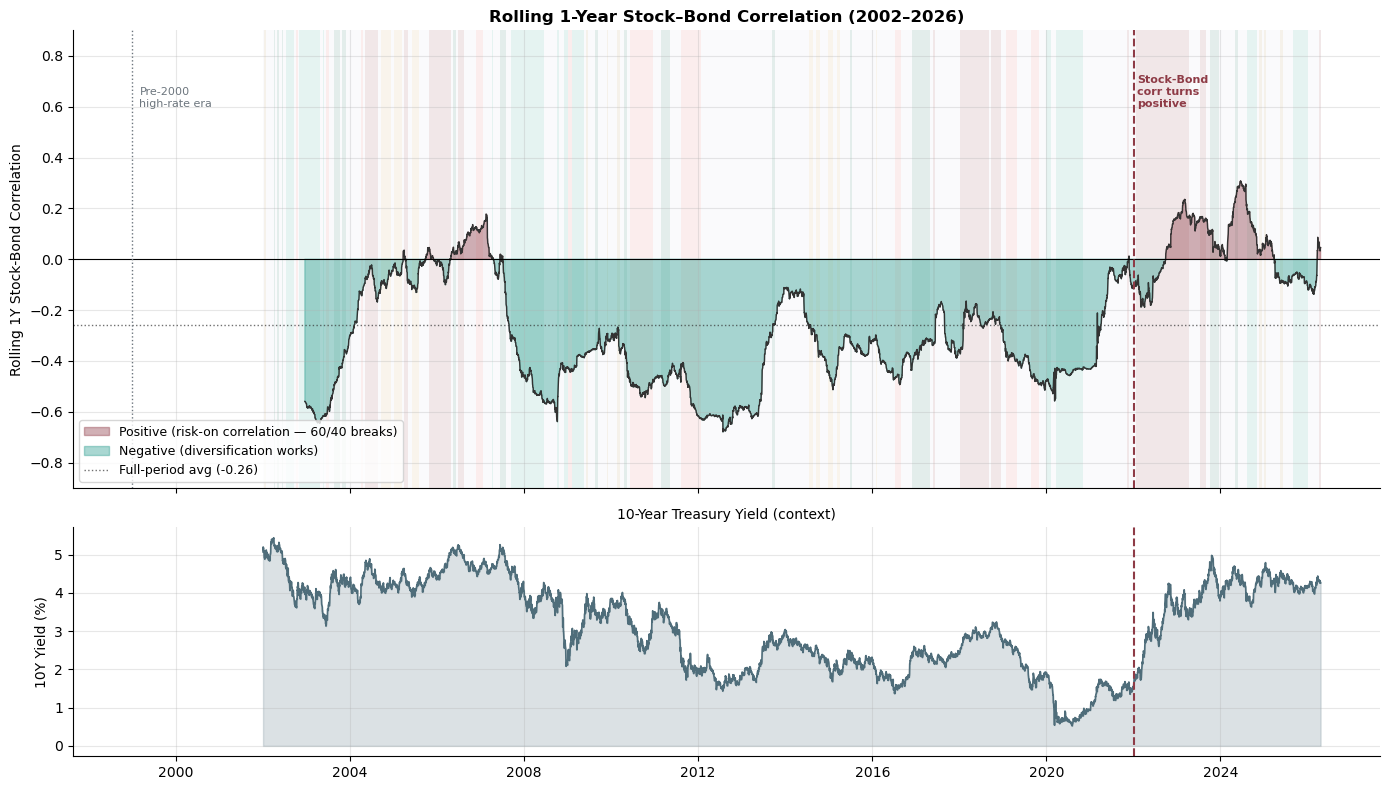

Saved → correlation_break.png


In [5]:
# Rolling 1Y stock-bond correlation 
roll_corr = ret['stock'].rolling(252).corr(ret['bond'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

regime_aligned_ret = reg['regime_filtered'].reindex(ret.index, method='ffill')
add_regime_bands(ax1, regime_aligned_ret)

# Fill areas
ax1.fill_between(roll_corr.index, roll_corr, 0,
                 where=roll_corr >= 0,
                 color='#8E3B46', alpha=0.4, label='Positive (risk-on correlation — 60/40 breaks)')
ax1.fill_between(roll_corr.index, roll_corr, 0,
                 where=roll_corr < 0,
                 color='#2A9D8F', alpha=0.4, label='Negative (diversification works)')
ax1.plot(roll_corr.index, roll_corr, color='#333333', linewidth=1)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline(roll_corr.mean(), color='#333333', linewidth=1, linestyle=':', alpha=0.7,
           label=f'Full-period avg ({roll_corr.mean():.2f})')

# Annotate 2022 break
ax1.axvline(pd.Timestamp('2022-01-01'), color='#8E3B46', linewidth=1.5, linestyle='--')
ax1.text(pd.Timestamp('2022-02-01'), 0.6, 'Stock-Bond\ncorr turns\npositive', fontsize=8,
         color='#8E3B46', fontweight='bold')
ax1.axvline(pd.Timestamp('1999-01-01'), color='#6C757D', linewidth=1, linestyle=':')
ax1.text(pd.Timestamp('1999-03-01'), 0.6, "Pre-2000\nhigh-rate era", fontsize=8, color='#6C757D')

ax1.set_ylabel('Rolling 1Y Stock-Bond Correlation')
ax1.set_title('Rolling 1-Year Stock–Bond Correlation (2002–2026)', fontsize=12, fontweight='bold')
ax1.legend(loc='lower left', fontsize=9)
ax1.set_ylim(-0.9, 0.9)

# Bottom: 10Y yield for context
y10 = reg['y10'].reindex(ret.index, method='ffill')
ax2.plot(y10.index, y10, color=COLORS['bond'], linewidth=1.2)
ax2.fill_between(y10.index, y10, alpha=0.2, color=COLORS['bond'])
ax2.set_ylabel('10Y Yield (%)')
ax2.set_title('10-Year Treasury Yield (context)', fontsize=10)
ax2.axvline(pd.Timestamp('2022-01-01'), color='#8E3B46', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig(OUT / 'correlation_break.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → correlation_break.png')

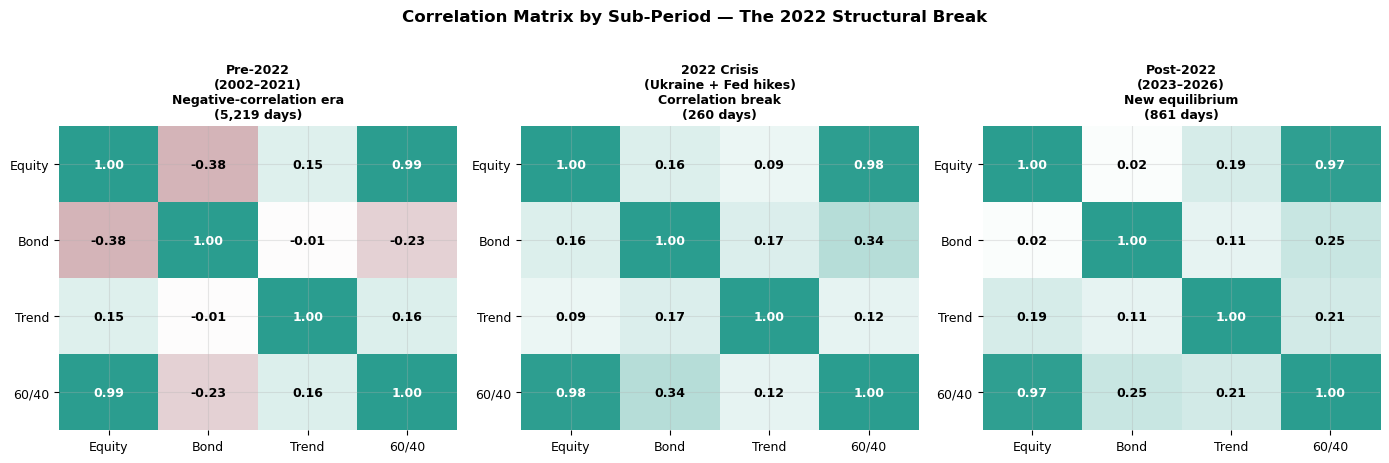

Saved → correlation_matrices.png
Pre-2022                  | Stock-Bond: -0.378 | Stock-Trend: +0.152 | Bond-Trend: -0.012
2022 Crisis               | Stock-Bond: +0.161 | Stock-Trend: +0.090 | Bond-Trend: +0.167
Post-2022                 | Stock-Bond: +0.018 | Stock-Trend: +0.189 | Bond-Trend: +0.110


In [6]:
# ── Correlation matrices: 3 sub-periods ──────────────────────────────────────
periods = {
    'Pre-2022\n(2002–2021)\nNegative-correlation era':  ('2002-01-01', '2021-12-31'),
    '2022 Crisis\n(Ukraine + Fed hikes)\nCorrelation break': ('2022-01-01', '2022-12-31'),
    'Post-2022\n(2023–2026)\nNew equilibrium':           ('2023-01-01', None),
}

cols = ['stock', 'bond', 'trend', '6040']
labels = ['Equity', 'Bond', 'Trend', '60/40']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

cmap = LinearSegmentedColormap.from_list('rg', ['#8E3B46', 'white', '#2A9D8F'])

for ax, (title, (start, end)) in zip(axes, periods.items()):
    sub = ret.loc[start:end, cols].dropna()
    corr = sub.corr()
    corr.index   = labels
    corr.columns = labels

    ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr.values[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                   fontsize=9, fontweight='bold', color=color)

    n_days = len(sub)
    ax.set_title(f'{title}\n({n_days:,} days)', fontsize=9, fontweight='bold')
    ax.spines[:].set_visible(False)

fig.suptitle('Correlation Matrix by Sub-Period — The 2022 Structural Break',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'correlation_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → correlation_matrices.png')

# Print summary
for title, (start, end) in periods.items():
    sub = ret.loc[start:end, cols].dropna()
    c = sub.corr()
    sb_corr = c.loc['stock', 'bond']
    st_corr = c.loc['stock', 'trend']
    bt_corr = c.loc['bond', 'trend']
    print(f'{title.split(chr(10))[0]:25s} | Stock-Bond: {sb_corr:+.3f} | Stock-Trend: {st_corr:+.3f} | Bond-Trend: {bt_corr:+.3f}')

---
## Section 3 — Regime Frequency Evolution

The steepening bias thesis claims that **deficit and debt dynamics will structurally push long yields up relative to short yields** — biasing the curve toward steepening regimes. Let's examine the historical frequency of steepener vs flattener regimes by decade and ask whether recent history supports or contradicts that thesis.

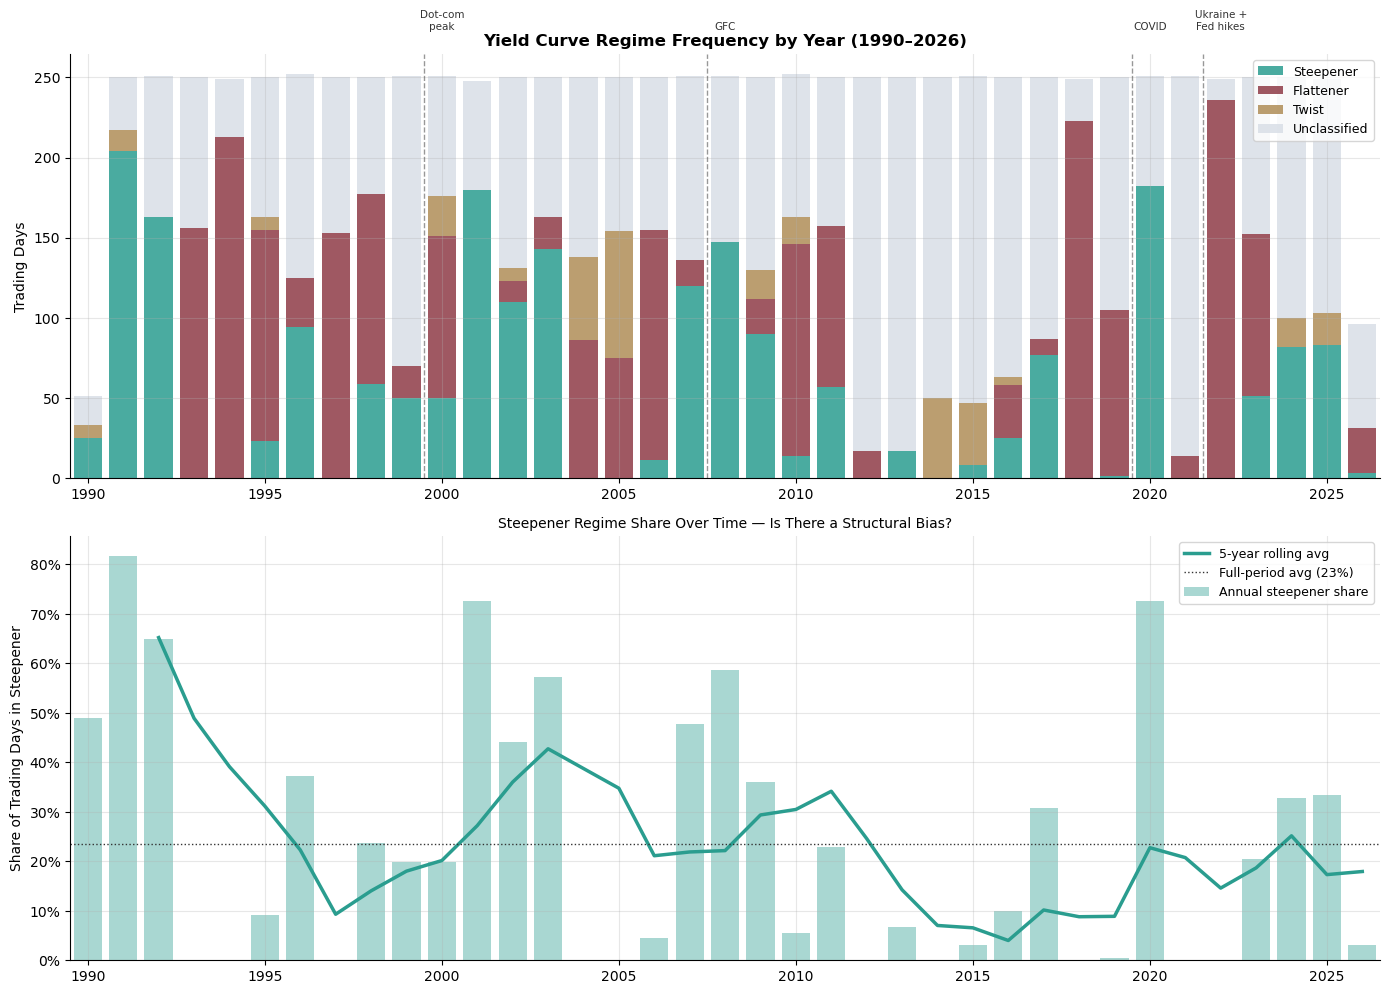

Saved → regime_frequency_evolution.png

Steepener share by decade:
  1990s: Steepener 27% | Flattener 36% | Unclassified 36%
  2000s: Steepener 34% | Flattener 19% | Unclassified 40%
  2010s: Steepener 8% | Flattener 25% | Unclassified 63%
  2020s: Steepener 25% | Flattener 24% | Unclassified 49%

Current regime (as of 2026-05-19): Bear Flattener


In [7]:
# Regime days by year 
reg_clean = reg[['regime_filtered', 'y2', 'y10', 'S']].copy()
reg_clean['year'] = reg_clean.index.year

# Group into steepener / flattener / twist / unclassified
def bucket(r):
    if not isinstance(r, str):
        return 'Unclassified'
    if 'Steepener' in r and 'Twist' not in r:
        return 'Steepener'
    if 'Flattener' in r and 'Twist' not in r:
        return 'Flattener'
    if 'Twist' in r:
        return 'Twist'
    return 'Unclassified'

reg_clean['bucket'] = reg_clean['regime_filtered'].apply(bucket)

by_year = (reg_clean.groupby(['year', 'bucket'])
           .size().unstack(fill_value=0))

# Ensure all columns present
for col in ['Steepener', 'Flattener', 'Twist', 'Unclassified']:
    if col not in by_year.columns:
        by_year[col] = 0
by_year = by_year[['Steepener', 'Flattener', 'Twist', 'Unclassified']]

# Figure: stacked bar 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

bucket_colors = {
    'Steepener':   '#2A9D8F',
    'Flattener':   '#8E3B46',
    'Twist':       '#B08D57',
    'Unclassified':'#D9DEE7',
}

bottom = np.zeros(len(by_year))
for col in ['Steepener', 'Flattener', 'Twist', 'Unclassified']:
    ax1.bar(by_year.index, by_year[col], bottom=bottom,
           color=bucket_colors[col], label=col, alpha=0.85)
    bottom += by_year[col].values

# Macro event annotations
macro_events = {
    2000: 'Dot-com\npeak', 2008: 'GFC', 2020: 'COVID',
    2022: 'Ukraine +\nFed hikes'
}
for yr, label in macro_events.items():
    ax1.axvline(yr - 0.5, color='#333333', linewidth=1, linestyle='--', alpha=0.5)
    ax1.text(yr, 280, label, fontsize=7.5, ha='center', color='#333333')

ax1.set_ylabel('Trading Days')
ax1.set_title('Yield Curve Regime Frequency by Year (1990–2026)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(by_year.index.min() - 0.5, by_year.index.max() + 0.5)

# Bottom: rolling 5Y steepener share
yearly_pct = by_year['Steepener'] / by_year.sum(axis=1)
rolling_5y = yearly_pct.rolling(5, min_periods=3).mean()

ax2.bar(yearly_pct.index, yearly_pct, color='#2A9D8F', alpha=0.4, label='Annual steepener share')
ax2.plot(rolling_5y.index, rolling_5y, color='#2A9D8F', linewidth=2.5, label='5-year rolling avg')
ax2.axhline(yearly_pct.mean(), color='#333333', linewidth=1, linestyle=':', label=f'Full-period avg ({yearly_pct.mean():.0%})')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('Share of Trading Days in Steepener')
ax2.set_title('Steepener Regime Share Over Time — Is There a Structural Bias?', fontsize=10)
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim(yearly_pct.index.min() - 0.5, yearly_pct.index.max() + 0.5)

plt.tight_layout()
plt.savefig(OUT / 'regime_frequency_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → regime_frequency_evolution.png')

# Decade summary
print()
print('Steepener share by decade:')
reg_clean['decade'] = (reg_clean['year'] // 10) * 10
decade_pct = (reg_clean.groupby(['decade', 'bucket']).size().unstack(fill_value=0)
              .assign(total=lambda x: x.sum(axis=1))
              .assign(steepener_pct=lambda x: x.get('Steepener', 0) / x['total']))
for decade, row in decade_pct.iterrows():
    print(f'  {decade}s: Steepener {row["steepener_pct"]:.0%} | Flattener {row.get("Flattener", 0)/row["total"]:.0%} | Unclassified {row.get("Unclassified", 0)/row["total"]:.0%}')

print()
current_regime = reg['regime_filtered'].dropna().iloc[-1]
print(f'Current regime (as of {reg.index[-1].date()}): {current_regime}')

---
## Section 4 — Sub-Period MV Analysis

The full-history optimizer is trained on 20+ years of data dominated by a **negative stock-bond correlation** era (~-0.38 pre-2022), which made bonds look like excellent diversifiers and suppressed Trend's marginal contribution.

**Question:** If you retrained the optimizer using only post-COVID / post-Ukraine data — does it make better out-of-sample decisions in 2025–2026?

**Setup (no lookahead bias):**
- **Full-history optimizer**: trained on 2002–2024, applied to 2025–present
- **Post-2022 optimizer**: trained on Jan 2022–Dec 2024 only, applied to 2025–present
- **Evaluation period**: Jan 2025–present (~16 months, fully out-of-sample for both)

In [68]:
# ── Optimizer functions ───────────────────────────────────────────────────────

def simplex_projection(v: np.ndarray) -> np.ndarray:
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - 1.0
    ind = np.arange(1, n + 1)
    cond = u - cssv / ind > 0
    rho_idx = np.where(cond)[0]
    if len(rho_idx) == 0:
        return np.ones(n) / n
    rho = rho_idx[-1]
    theta = cssv[rho] / (rho + 1)
    return np.maximum(v - theta, 0.0)


def long_only_tangency(window: pd.DataFrame) -> np.ndarray:
    mu = TRADING_DAYS * window.mean().values
    Sg = TRADING_DAYS * window.cov().values
    try:
        inv = np.linalg.inv(Sg)
    except np.linalg.LinAlgError:
        return np.ones(len(mu)) / len(mu)
    raw = inv @ mu
    s = raw.sum()
    if not np.isfinite(s) or s <= 0:
        raw_mv = inv @ np.ones(len(mu))
        s_mv = raw_mv.sum()
        raw = raw_mv / s_mv if (s_mv > 0 and np.isfinite(s_mv)) else np.ones(len(mu)) / len(mu)
    else:
        raw = raw / s
    return simplex_projection(raw)


def portfolio_stats(r: pd.Series) -> dict:
    r = r.dropna()
    ann_ret = TRADING_DAYS * r.mean()
    ann_vol = np.sqrt(TRADING_DAYS) * r.std()
    nav     = (1 + r).cumprod()
    return {
        'Ann Return': ann_ret,
        'Ann Vol':    ann_vol,
        'Sharpe':     ann_ret / ann_vol if ann_vol > 0 else np.nan,
        'Max DD':     (nav / nav.cummax() - 1).min(),
    }


# ── Two optimizers — both trained strictly through Dec 2024 ──────────────────
R = ret[['stock', 'bond', 'trend']].dropna()

TRAIN_END  = '2024-12-31'
EVAL_START = '2025-01-01'

w_full = long_only_tangency(R.loc['2002-01-01': TRAIN_END])   # full history
w_post = long_only_tangency(R.loc['2022-01-01': TRAIN_END])   # post-2022 only

# ── Evaluate on the same out-of-sample period: 2025–present ──────────────────
eval_period = R.loc[EVAL_START:]

stats_full = portfolio_stats((eval_period * w_full).sum(axis=1))
stats_post = portfolio_stats((eval_period * w_post).sum(axis=1))
stats_6040 = portfolio_stats(ret.loc[EVAL_START:, '6040'])

# ── Results table ─────────────────────────────────────────────────────────────
rows = {
    'Full-history optimizer (trained 2002–2024)':      {**{'Equity': w_full[0], 'Bond': w_full[1], 'Trend': w_full[2]}, **stats_full},
    'Post-2022 optimizer (trained Jan 2022–Dec 2024)': {**{'Equity': w_post[0], 'Bond': w_post[1], 'Trend': w_post[2]}, **stats_post},
    '60/40 Benchmark':                                 {**{'Equity': 0.6,        'Bond': 0.4,        'Trend': 0.0},       **stats_6040},
}

print(f'{"":50s} {"Equity":>8} {"Bond":>8} {"Trend":>8}  |  {"Sharpe":>7} {"Max DD":>8}')
print('-' * 95)
for name, r in rows.items():
    print(f'{name:50s} {r["Equity"]:>8.1%} {r["Bond"]:>8.1%} {r["Trend"]:>8.1%}  |  {r["Sharpe"]:>7.2f} {r["Max DD"]:>8.1%}')

print()
print(f'Training: full history = 2002–2024 | post-2022 = Jan 2022–Dec 2024')
print(f'Evaluation: {eval_period.index[0].date()} to {eval_period.index[-1].date()} '
      f'({len(eval_period)} trading days — out-of-sample for both)')

                                                     Equity     Bond    Trend  |   Sharpe   Max DD
-----------------------------------------------------------------------------------------------
Full-history optimizer (trained 2002–2024)            14.4%    64.2%    21.5%  |     2.13    -3.3%
Post-2022 optimizer (trained Jan 2022–Dec 2024)        3.5%    47.3%    49.2%  |     2.09    -3.5%
60/40 Benchmark                                       60.0%    40.0%     0.0%  |     1.15   -10.9%

Training: full history = 2002–2024 | post-2022 = Jan 2022–Dec 2024
Evaluation: 2025-01-01 to 2026-04-20 (339 trading days — out-of-sample for both)


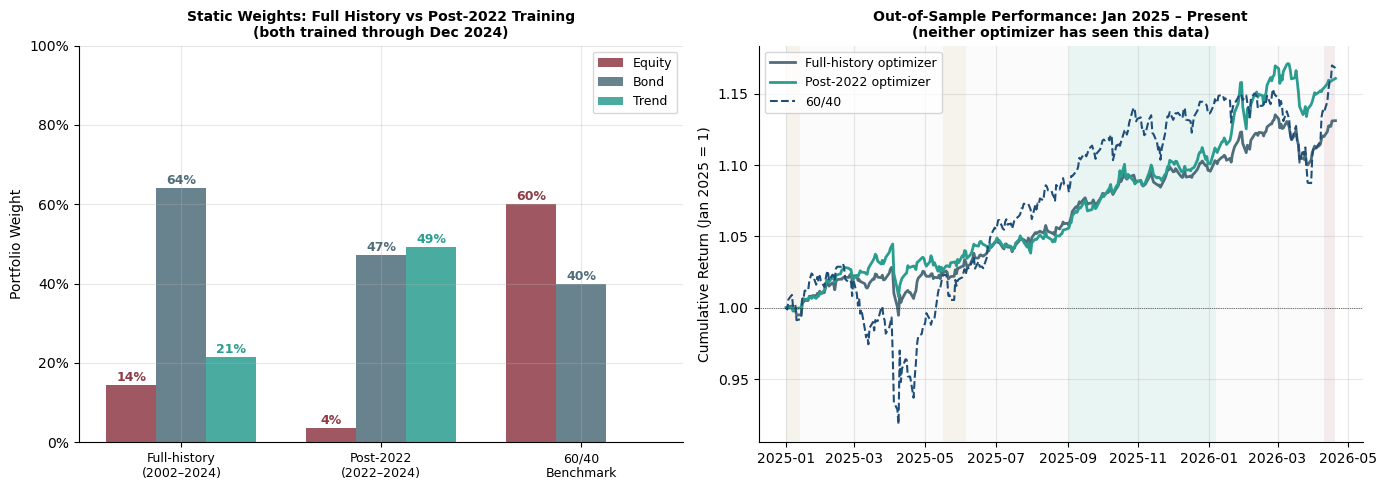

Saved → subperiod_mv_weights.png


In [69]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: weights side by side
names   = ['Full-history\n(2002–2024)', 'Post-2022\n(2022–2024)', '60/40\nBenchmark']
weights = [
    [w_full[0], w_full[1], w_full[2]],
    [w_post[0], w_post[1], w_post[2]],
    [0.6,       0.4,       0.0],
]

x     = np.arange(len(names))
width = 0.25

for i, (col, label) in enumerate(zip([COLORS['stock'], COLORS['bond'], COLORS['trend']],
                                      ['Equity', 'Bond', 'Trend'])):
    vals = [w[i] for w in weights]
    bars = ax1.bar(x + (i - 1) * width, vals, width, color=col, label=label, alpha=0.85)
    for bar, v in zip(bars, vals):
        if v > 0.01:
            ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                     f'{v:.0%}', ha='center', fontsize=9, color=col, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(names, fontsize=9)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylabel('Portfolio Weight')
ax1.set_title('Static Weights: Full History vs Post-2022 Training\n(both trained through Dec 2024)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1.0)

# Right: cumulative return — out-of-sample period Jan 2025 onwards
r_full_nav = (1 + (eval_period * w_full).sum(axis=1)).cumprod()
r_post_nav = (1 + (eval_period * w_post).sum(axis=1)).cumprod()
r_6040_nav = (1 + ret.loc[EVAL_START:, '6040']).cumprod()

ax2.plot(r_full_nav.index, r_full_nav, color=COLORS['bond'],  linewidth=2,   label='Full-history optimizer')
ax2.plot(r_post_nav.index, r_post_nav, color=COLORS['trend'], linewidth=2,   label='Post-2022 optimizer')
ax2.plot(r_6040_nav.index, r_6040_nav, color=COLORS['6040'],  linewidth=1.5, label='60/40', linestyle='--')

regime_eval = reg['regime_filtered'].reindex(eval_period.index, method='ffill')
add_regime_bands(ax2, regime_eval, alpha=0.10)

ax2.set_ylabel('Cumulative Return (Jan 2025 = 1)')
ax2.set_title('Out-of-Sample Performance: Jan 2025 – Present\n(neither optimizer has seen this data)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.axhline(1, color='black', linewidth=0.5, linestyle=':')

plt.tight_layout()
plt.savefig(OUT / 'subperiod_mv_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → subperiod_mv_weights.png')

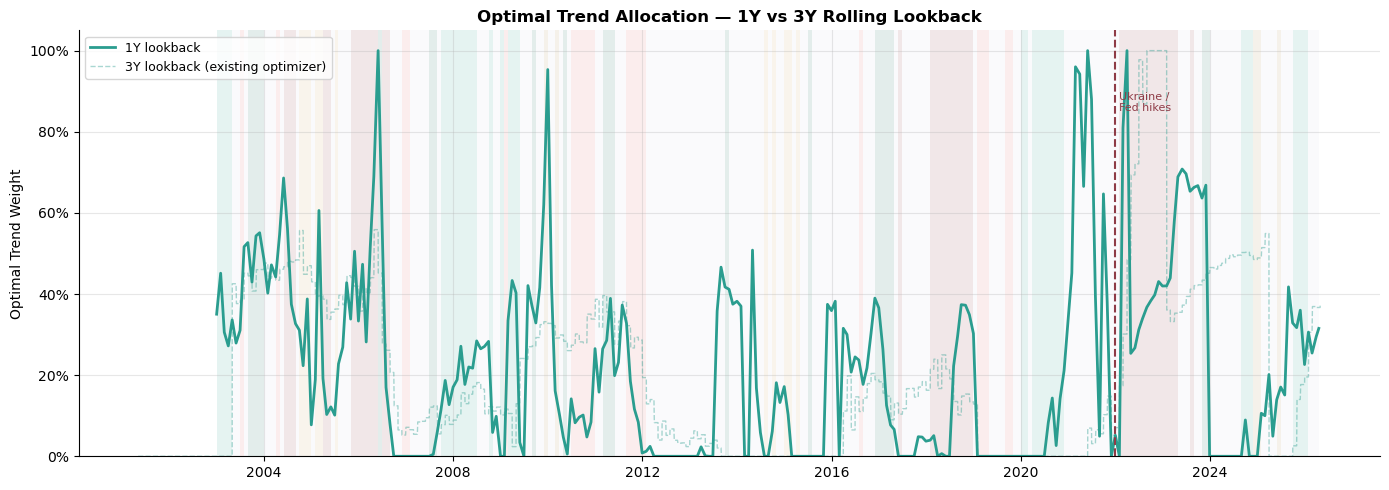

Saved → rolling_1y_vs_3y_trend_weight.png

1Y lookback — post-2022 avg Trend weight: 30.1%
3Y lookback — post-2022 avg Trend weight: 43.4%


In [11]:
# Rolling 1Y tangency weight for Trend
R_aligned = ret[['stock', 'bond', 'trend']].dropna()

# Get the actual last trading-day position for each calendar month
# resample('ME') labels by calendar month-end, which may not be a trading day —
# so we carry the integer position, then look up the real date.
month_end_positions = (
    pd.Series(range(len(R_aligned)), index=R_aligned.index)
    .resample('ME').last()
    .dropna()
    .astype(int)
)

rolling_weights = []
LOOKBACK_1Y = 252

for cal_me, pos in month_end_positions.items():
    if pos < LOOKBACK_1Y:
        continue
    actual_date = R_aligned.index[pos]
    window = R_aligned.iloc[pos - LOOKBACK_1Y: pos + 1]
    w = long_only_tangency(window)
    rolling_weights.append({'date': actual_date, 'w_trend_1y': w[2],
                            'w_stock_1y': w[0], 'w_bond_1y': w[1]})

rw_df = pd.DataFrame(rolling_weights).set_index('date')

fig, ax = plt.subplots(figsize=(14, 5))

regime_me = reg['regime_filtered'].reindex(rw_df.index, method='ffill')
add_regime_bands(ax, regime_me, alpha=0.12)

ax.plot(rw_df.index, rw_df['w_trend_1y'], color=COLORS['trend'], linewidth=2, label='1Y lookback')
ax.plot(dw.index, dw['w_trend'], color=COLORS['trend'], linewidth=1,
       alpha=0.4, linestyle='--', label='3Y lookback (existing optimizer)')

ax.axvline(pd.Timestamp('2022-01-01'), color='#8E3B46', linewidth=1.5, linestyle='--')
ax.text(pd.Timestamp('2022-02-01'), 0.85, 'Ukraine /\nFed hikes', fontsize=8, color='#8E3B46')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Optimal Trend Weight')
ax.set_title('Optimal Trend Allocation — 1Y vs 3Y Rolling Lookback', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUT / 'rolling_1y_vs_3y_trend_weight.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → rolling_1y_vs_3y_trend_weight.png')

print(f"\n1Y lookback — post-2022 avg Trend weight: {rw_df.loc['2022-01-01':, 'w_trend_1y'].mean():.1%}")
print(f"3Y lookback — post-2022 avg Trend weight: {dw.loc['2022-01-01':, 'w_trend'].mean():.1%}")

---
## Section 5 — The Steepening Bias Thesis

The hypothesis: **rising deficit spending and debt supply structurally bias the yield curve toward steepening**, through two channels:
- **Bear steepener**: More long-duration Treasury supply → term premium rises → long yields rise faster than short yields
- **Bull steepener**: Fed cuts short rates to manage debt servicing costs, while long yields stay elevated (fiscal risk premium)

Both channels favour Trend — which earns Sharpe **1.73** in Bull Steepener and **0.56** in Bear Steepener — over a static bond-heavy 60/40.

Three panels below:
1. **2Y/10Y spread** — where the curve is steepening vs inverted, overlaid with regime bands
2. **US deficit and debt as % of GDP** — the structural pressure building (requires local FRED CSVs)
3. **2Y vs 10Y yields separately** — shows which leg is driving spread changes (Fed-controlled short end vs market-driven long end)

In [12]:
# Load FRED data from data/ 
def load_fred_csv(filename: str) -> pd.Series:
    df = pd.read_csv(DATA / filename)
    df.columns = ['date', 'value']
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).set_index('date')
    return pd.to_numeric(df['value'], errors='coerce').dropna()

deficit_pct = load_fred_csv('FYFSGDA188S.csv')
debt_pct    = load_fred_csv('GFDEGDQ188S.csv')

print(f'Deficit/GDP: {deficit_pct.index.min().year}–{deficit_pct.index.max().year} ({len(deficit_pct)} obs)')
print(f'Debt/GDP:    {debt_pct.index.min().year}–{debt_pct.index.max().year} ({len(debt_pct)} obs)')

Deficit/GDP: 1929–2025 (97 obs)
Debt/GDP:    1966–2025 (240 obs)


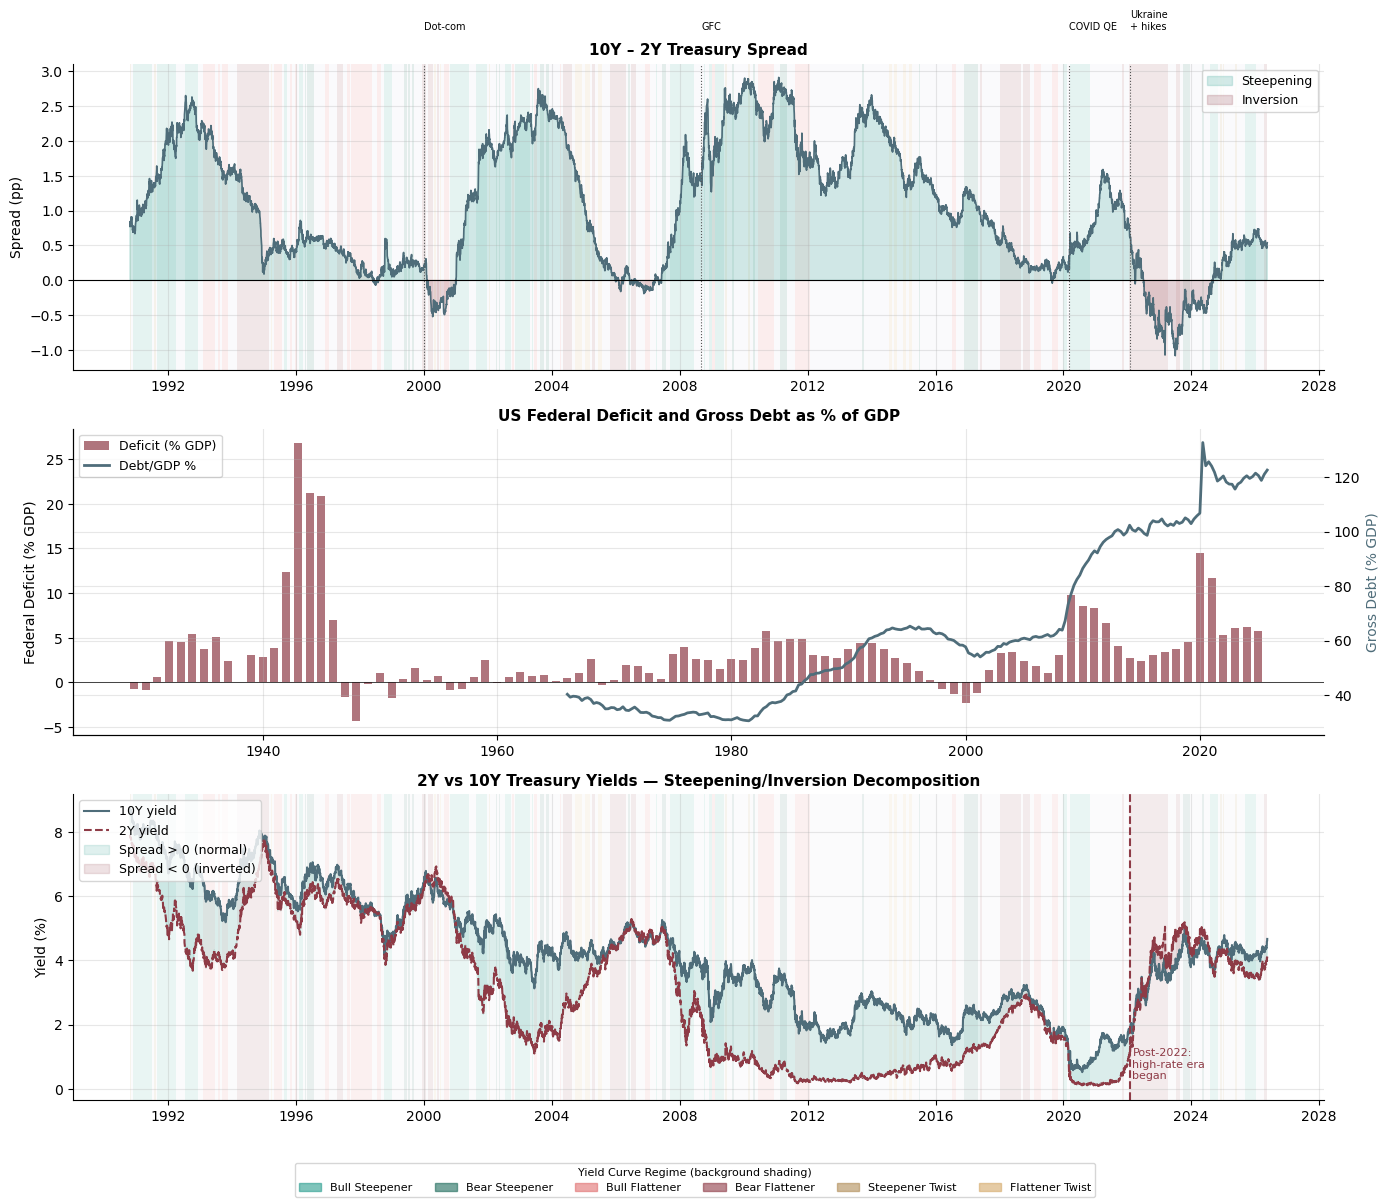

Saved → steepening_bias_thesis.png


In [13]:
# Chart: 2Y/10Y spread + deficit/debt + yield decomposition 
spread = reg['S']
y2     = reg['y2']
y10    = reg['y10']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

# Panel 1: 2Y/10Y spread with regime bands 
ax1 = axes[0]
add_regime_bands(ax1, reg['regime_filtered'], alpha=0.12)
ax1.plot(spread.index, spread, color=COLORS['bond'], linewidth=1.2)
ax1.fill_between(spread.index, spread, 0,
                 where=spread >= 0, color='#2A9D8F', alpha=0.2, label='Steepening')
ax1.fill_between(spread.index, spread, 0,
                 where=spread < 0, color='#8E3B46', alpha=0.2, label='Inversion')
ax1.axhline(0, color='black', linewidth=0.8)

for d, lbl in {'2000-01-01': 'Dot-com', '2008-09-01': 'GFC',
               '2020-03-01': 'COVID QE', '2022-02-01': 'Ukraine\n+ hikes'}.items():
    ax1.axvline(pd.Timestamp(d), color='#555', linewidth=0.8, linestyle=':')
    ax1.text(pd.Timestamp(d), 3.6, lbl, fontsize=7, ha='left')

ax1.set_ylabel('Spread (pp)')
ax1.set_title('10Y – 2Y Treasury Spread', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')

# Panel 2: Deficit and Debt as % of GDP 
ax2  = axes[1]
ax2b = ax2.twinx()

ax2.bar(deficit_pct.index, -deficit_pct, width=250,
        color='#8E3B46', alpha=0.7, label='Deficit (% GDP)')
ax2b.plot(debt_pct.index, debt_pct, color='#4F6D7A', linewidth=2, label='Debt/GDP %')
ax2b.set_ylabel('Gross Debt (% GDP)', color='#4F6D7A')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Federal Deficit (% GDP)')
ax2.set_title('US Federal Deficit and Gross Debt as % of GDP', fontsize=11, fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

# Panel 3: 2Y vs 10Y yields — steepening channel decomposition 
ax3 = axes[2]
add_regime_bands(ax3, reg['regime_filtered'], alpha=0.10)

ax3.plot(y10.index, y10, color=COLORS['bond'],  linewidth=1.5, label='10Y yield')
ax3.plot(y2.index,  y2,  color=COLORS['stock'], linewidth=1.5, label='2Y yield', linestyle='--')
ax3.fill_between(y10.index, y10, y2,
                 where=(y10 >= y2), color='#2A9D8F', alpha=0.15, label='Spread > 0 (normal)')
ax3.fill_between(y10.index, y10, y2,
                 where=(y10 < y2),  color='#8E3B46', alpha=0.15, label='Spread < 0 (inverted)')

ax3.axvline(pd.Timestamp('2022-02-01'), color='#8E3B46', linewidth=1.5, linestyle='--')
ax3.text(pd.Timestamp('2022-03-01'), 0.3, 'Post-2022:\nhigh-rate era\nbegan', fontsize=8, color='#8E3B46')

ax3.set_ylabel('Yield (%)')
ax3.set_title('2Y vs 10Y Treasury Yields — Steepening/Inversion Decomposition',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=9, loc='upper left')

patches = [mpatches.Patch(color=c, label=r, alpha=0.6)
           for r, c in REGIME_COLORS.items() if r != 'Unclassified']
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=8,
           title='Yield Curve Regime (background shading)', title_fontsize=8, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(OUT / 'steepening_bias_thesis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → steepening_bias_thesis.png')

In [14]:
# Regime-conditional Trend performance recap
q1    = pd.read_csv(REG_OUT / 'q1_trend_by_regime.csv').set_index('Regime')
avg_w = pd.read_csv(REG_OUT / 'q3_avg_weights_by_regime.csv').set_index('Regime')

REGIME_ORDER = ['Bull Steepener', 'Bear Steepener', 'Bull Flattener',
                'Bear Flattener', 'Steepener Twist', 'Flattener Twist']

summary = pd.DataFrame(index=REGIME_ORDER)
summary['Trend Sharpe'] = q1['Sharpe'].reindex(REGIME_ORDER)
summary['Avg Trend Wt'] = avg_w['Avg Trend weight'].reindex(REGIME_ORDER)
summary['Steepener?']   = summary.index.map(lambda r: 'Steepener' in r)

print('Regime-conditional Trend performance vs optimizer allocation:')
print(summary.to_string(float_format='{:.2f}'.format))

print()
print('Key insight — Steepening bias implications:')
print('  Bull Steepener: Trend Sharpe 1.73, but optimizer gives only  8.4% (correlation-driven)')
print('  Bear Steepener: Trend Sharpe 0.56, optimizer gives          27.4%')
print()
print('  If deficit/debt dynamics shift the structural regime toward steepeners:')
print('  → Trend\'s standalone performance improves (esp. Bull Steepener)')
print('  → Stock-bond negative correlation likely persists (steepeners = growth + rate mix)')
print('  → The case for a HIGHER Trend floor (vs current 8-27% avg) strengthens')
print()

latest_sp  = spread.dropna().iloc[-1]
latest_y2  = y2.dropna().iloc[-1]
latest_y10 = y10.dropna().iloc[-1]
as_of      = spread.dropna().index[-1].date()
print(f'  Current yield curve (as of {as_of}):')
print(f'    2Y yield     = {latest_y2:.2f}%')
print(f'    10Y yield    = {latest_y10:.2f}%')
print(f'    2Y/10Y spread= {latest_sp:.2f}pp  ({"inverted" if latest_sp < 0 else "steepening"})')
print(f'    Deficit/GDP  = {-deficit_pct.dropna().iloc[-1]:.1f}%')
print(f'    Debt/GDP     = {debt_pct.dropna().iloc[-1]:.0f}%')

Regime-conditional Trend performance vs optimizer allocation:
                 Trend Sharpe  Avg Trend Wt  Steepener?
Bull Steepener           1.73          0.08        True
Bear Steepener           0.56          0.27        True
Bull Flattener           0.25          0.19       False
Bear Flattener           0.20          0.44       False
Steepener Twist         -0.12          0.27        True
Flattener Twist          2.12          0.25       False

Key insight — Steepening bias implications:
  Bull Steepener: Trend Sharpe 1.73, but optimizer gives only  8.4% (correlation-driven)
  Bear Steepener: Trend Sharpe 0.56, optimizer gives          27.4%

  If deficit/debt dynamics shift the structural regime toward steepeners:
  → Trend's standalone performance improves (esp. Bull Steepener)
  → Stock-bond negative correlation likely persists (steepeners = growth + rate mix)
  → The case for a HIGHER Trend floor (vs current 8-27% avg) strengthens

  Current yield curve (as of 2026-05-19):
  

---
## Summary

| Question | Finding |
|----------|----------|
| **Why low Trend allocation?** | MV optimizer is correlation-driven, not performance-driven. In good regimes (Bull Steepener), everything rallies together — Trend's diversification value drops, so does its weight. The 3Y window also lagged the 2022 Bear Flattener benefit and caused a cliff in 2025 when 2022 rolled off. |
| **Did 2022 break correlation structure?** | Yes. Stock-bond correlation flipped from ~-0.27 (20-year avg) to positive during 2022 — the first time since the late 1990s. Post-2022 it has partially normalised but remains higher than the pre-2022 baseline. Trend was the only true diversifier during the break. |
| **Does steepening bias justify more Trend?** | The historical regime data does **not yet** show a structural steepening dominance — 2023-2026 has been mostly Unclassified and Bear Flattener. But the forward thesis is plausible: rising debt supply → term premium repricing → structural steepening pressure. In a steepening world, Trend's expected Sharpe (1.73 in Bull Steep) is significantly higher than bonds'. A higher Trend floor than what the backward-looking MV prescribes is defensible. |

**Next questions to explore:**
- At what deficit/debt threshold does term premium historically reprice?
- Would a forward-looking regime prior (steepener 50% likely) shift the optimal Trend allocation materially?
- Is the current Bear Flattener (May 2026) a policy response (Fed holding rates) or structural (safe-haven demand for long Treasuries)?